<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/optimization_regularization/experiment_hyperparameter_tuning_bias_variance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

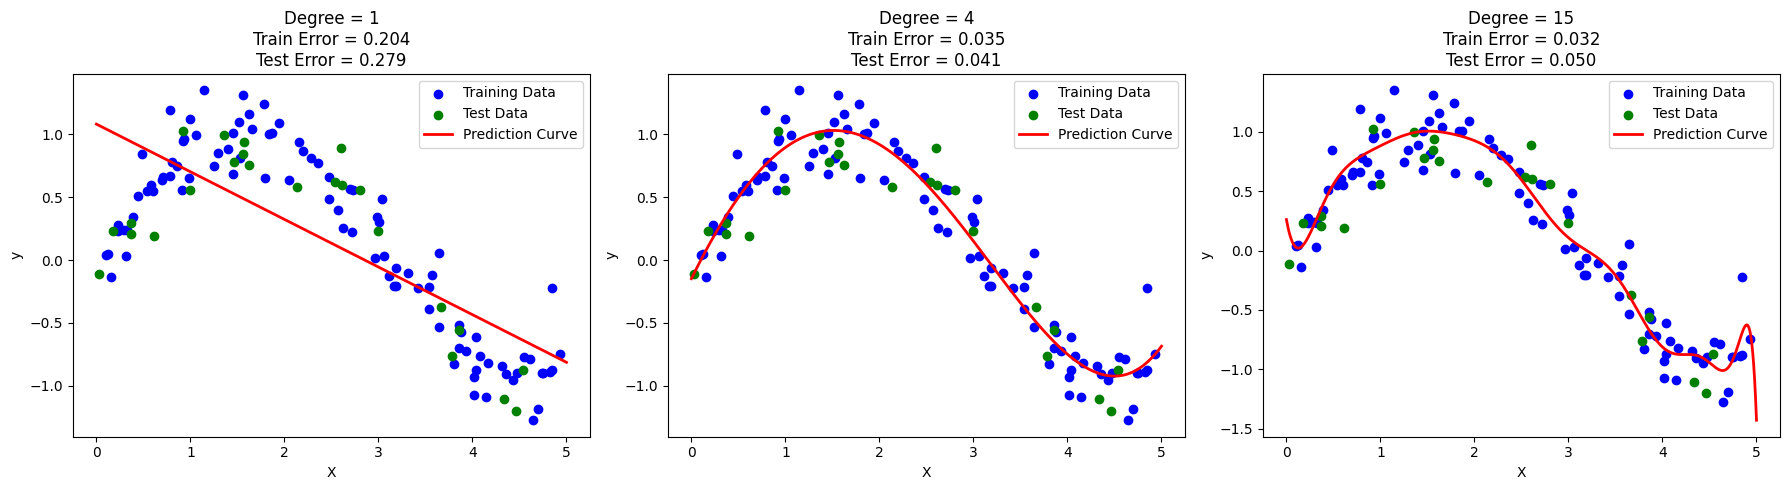


HYPERPARAMETER ANALYSIS
------------------------------------------------
Degree 1:
-> Simple Model
-> High Bias
-> Underfitting

Degree 4:
-> Balanced Complexity
-> Good Generalization

Degree 15:
-> Very Complex Model
-> High Variance
-> Overfitting
------------------------------------------------


In [1]:
# ============================================================
# HYPERPARAMETER IMPACT DEMO
# Polynomial Degree as Hyperparameter
# ============================================================

# STEP 1 — Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ============================================================
# STEP 2 — Create Dataset
# ============================================================

np.random.seed(42)

X = np.sort(5 * np.random.rand(120, 1), axis=0)

y = np.sin(X).ravel() + np.random.normal(
    0,
    0.2,
    120
)

# ============================================================
# STEP 3 — Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 4 — Different Hyperparameter Values
# ============================================================

degrees = [1, 4, 15]

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):

    # Polynomial Regression Model
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Error Calculation
    train_error = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_error = mean_squared_error(
        y_test,
        y_test_pred
    )

    # Smooth Curve
    X_plot = np.linspace(0, 5, 500).reshape(-1, 1)

    y_plot = model.predict(X_plot)

    # ========================================================
    # Plot
    # ========================================================

    plt.subplot(1, 3, i + 1)

    plt.scatter(
        X_train,
        y_train,
        color='blue',
        label='Training Data'
    )

    plt.scatter(
        X_test,
        y_test,
        color='green',
        label='Test Data'
    )

    plt.plot(
        X_plot,
        y_plot,
        color='red',
        linewidth=2,
        label='Prediction Curve'
    )

    plt.title(
        f"Degree = {degree}\n"
        f"Train Error = {train_error:.3f}\n"
        f"Test Error = {test_error:.3f}"
    )

    plt.xlabel("X")
    plt.ylabel("y")

    plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 5 — Conclusion
# ============================================================

print("\nHYPERPARAMETER ANALYSIS")
print("------------------------------------------------")

print("Degree 1:")
print("-> Simple Model")
print("-> High Bias")
print("-> Underfitting\n")

print("Degree 4:")
print("-> Balanced Complexity")
print("-> Good Generalization\n")

print("Degree 15:")
print("-> Very Complex Model")
print("-> High Variance")
print("-> Overfitting")

print("------------------------------------------------")

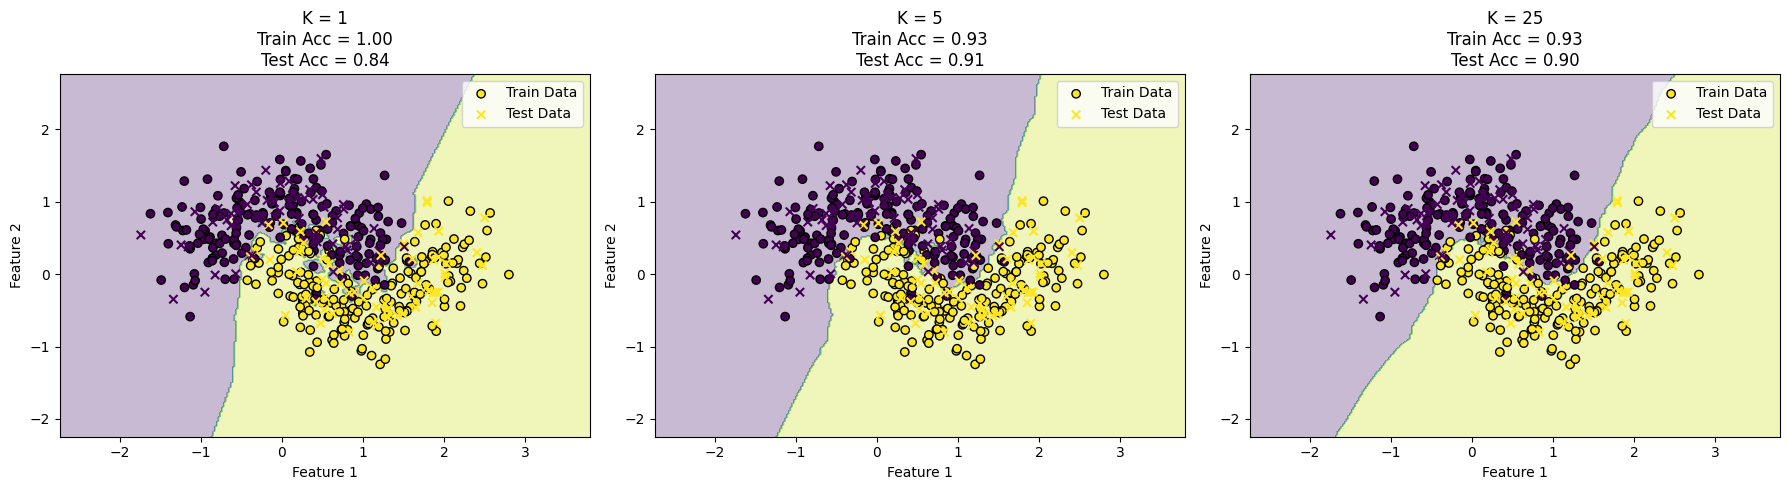


HYPERPARAMETER ANALYSIS RESULTS
   K Value  Train Accuracy  Test Accuracy
0        1        1.000000          0.840
1        5        0.930667          0.912
2       25        0.933333          0.896

INTERPRETATION
K = 1
-> Model memorizes training data
-> Overfitting
-> High Variance

K = 5
-> Balanced learning
-> Good generalization

K = 25
-> Too simple
-> Underfitting
-> High Bias


In [2]:
# ============================================================
# HYPERPARAMETER IMPACT ANALYSIS
# KNN CLASSIFIER DEMO
# ============================================================

# STEP 1 — Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# STEP 2 — Create Dataset
# ============================================================

X, y = make_moons(
    n_samples=500,
    noise=0.30,
    random_state=42
)

# ============================================================
# STEP 3 — Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# ============================================================
# STEP 4 — Different Hyperparameter Values
# ============================================================

k_values = [1, 5, 25]

train_accuracies = []
test_accuracies = []

plt.figure(figsize=(18, 5))

# ============================================================
# STEP 5 — Train Models
# ============================================================

for i, k in enumerate(k_values):

    # Create Model
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(
        y_train,
        y_train_pred
    )

    test_acc = accuracy_score(
        y_test,
        y_test_pred
    )

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # ========================================================
    # Decision Boundary
    # ========================================================

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # ========================================================
    # Plot
    # ========================================================

    plt.subplot(1, 3, i + 1)

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        edgecolor='k',
        label='Train Data'
    )

    plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        marker='x',
        label='Test Data'
    )

    plt.title(
        f"K = {k}\n"
        f"Train Acc = {train_acc:.2f}\n"
        f"Test Acc = {test_acc:.2f}"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 6 — Result Table
# ============================================================

results = pd.DataFrame({
    "K Value": k_values,
    "Train Accuracy": train_accuracies,
    "Test Accuracy": test_accuracies
})

print("\nHYPERPARAMETER ANALYSIS RESULTS")
print("================================================")
print(results)

# ============================================================
# STEP 7 — Interpretation
# ============================================================

print("\nINTERPRETATION")
print("================================================")

print("K = 1")
print("-> Model memorizes training data")
print("-> Overfitting")
print("-> High Variance\n")

print("K = 5")
print("-> Balanced learning")
print("-> Good generalization\n")

print("K = 25")
print("-> Too simple")
print("-> Underfitting")
print("-> High Bias")

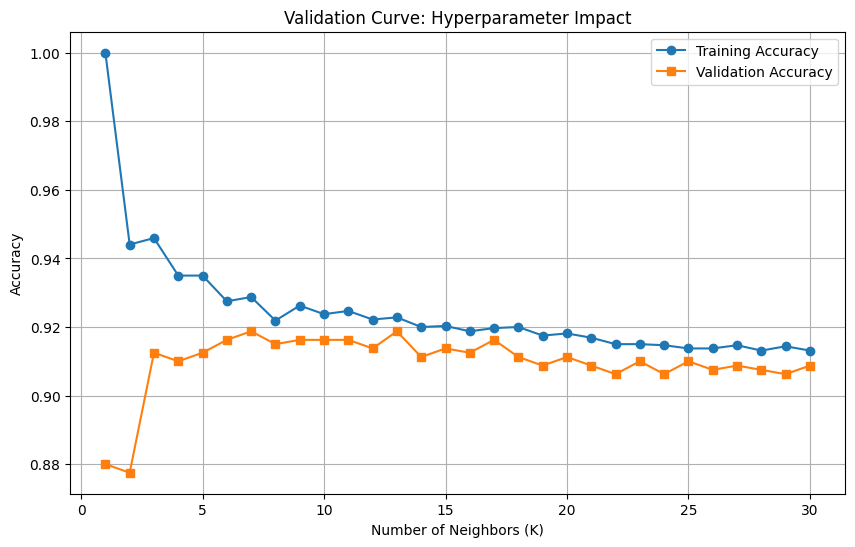


BEST HYPERPARAMETER
Best K Value: 7

CROSS VALIDATION
Cross Validation Scores:
[0.9     0.93125 0.9375  0.9125  0.9125 ]

Average CV Accuracy: 0.9187

MODEL EVALUATION
Accuracy  : 0.9050
Precision : 0.9010
Recall    : 0.9100
F1 Score  : 0.9055


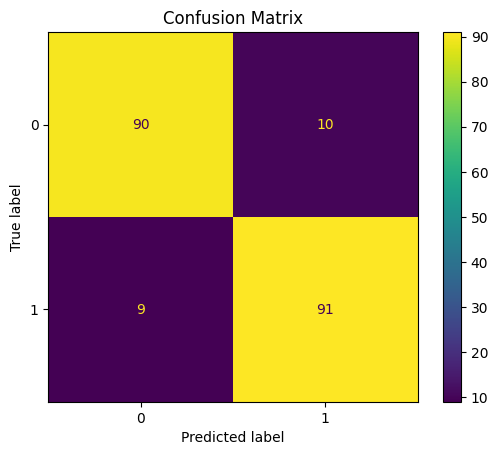

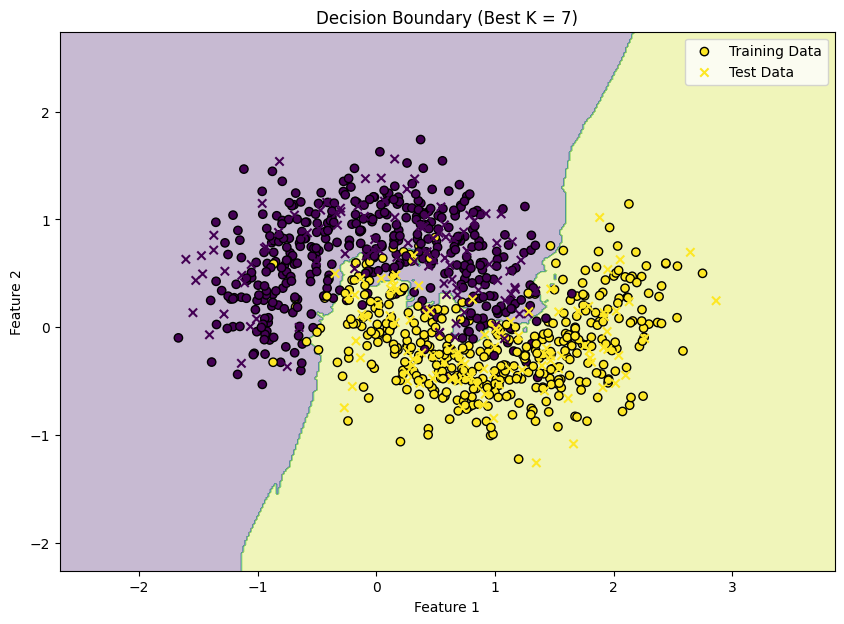


HYPERPARAMETER IMPACT ANALYSIS

1. Small K Values
   -> Complex boundaries
   -> Overfitting
   -> High Variance

2. Large K Values
   -> Simpler boundaries
   -> Underfitting
   -> High Bias

3. Optimal K
   -> Best balance between bias and variance
   -> Better generalization

4. GridSearchCV automatically selected
   the best hyperparameter using
   cross-validation.

5. Validation Curve clearly shows
   the tradeoff between:
   - Underfitting
   - Optimal fitting
   - Overfitting

DEMO COMPLETED SUCCESSFULLY


In [3]:
# ============================================================
# ULTIMATE HYPERPARAMETER ANALYSIS DEMO
# Industry-Level ML Workflow
# ============================================================

# FEATURES INCLUDED:
# ------------------------------------------------------------
# 1. Synthetic Dataset
# 2. Train / Validation / Test Logic
# 3. Cross Validation
# 4. Validation Curve
# 5. GridSearchCV
# 6. Bias-Variance Analysis
# 7. Decision Boundary Visualization
# 8. Multiple Metrics
# 9. Best Hyperparameter Selection
# 10. Professional Visualization
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

from sklearn.model_selection import (
    train_test_split,
    validation_curve,
    GridSearchCV,
    cross_val_score
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# STEP 2 — CREATE DATASET
# ============================================================

X, y = make_moons(
    n_samples=1000,
    noise=0.30,
    random_state=42
)

# ============================================================
# STEP 3 — SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# STEP 4 — VALIDATION CURVE
# Analyze Impact of Hyperparameter (K)
# ============================================================

param_range = np.arange(1, 31)

train_scores, validation_scores = validation_curve(
    KNeighborsClassifier(),
    X_train,
    y_train,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

# Mean Scores

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)

# ============================================================
# STEP 5 — PLOT VALIDATION CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    param_range,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    param_range,
    validation_mean,
    marker='s',
    label='Validation Accuracy'
)

plt.title("Validation Curve: Hyperparameter Impact")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# STEP 6 — GRID SEARCH CV
# Automatic Hyperparameter Tuning
# ============================================================

param_grid = {
    'n_neighbors': np.arange(1, 31)
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Best Model

best_k = grid_search.best_params_['n_neighbors']

best_model = grid_search.best_estimator_

print("\n================================================")
print("BEST HYPERPARAMETER")
print("================================================")

print(f"Best K Value: {best_k}")

# ============================================================
# STEP 7 — CROSS VALIDATION SCORE
# ============================================================

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\n================================================")
print("CROSS VALIDATION")
print("================================================")

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nAverage CV Accuracy: {cv_scores.mean():.4f}")

# ============================================================
# STEP 8 — TEST PREDICTIONS
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# STEP 9 — EVALUATION METRICS
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\n================================================")
print("MODEL EVALUATION")
print("================================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ============================================================
# STEP 10 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# STEP 11 — DECISION BOUNDARY
# ============================================================

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = best_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# ============================================================
# STEP 12 — PLOT DECISION BOUNDARY
# ============================================================

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor='k',
    label='Training Data'
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    marker='x',
    label='Test Data'
)

plt.title(
    f"Decision Boundary (Best K = {best_k})"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

# ============================================================
# STEP 13 — FINAL ANALYSIS
# ============================================================

print("\n================================================")
print("HYPERPARAMETER IMPACT ANALYSIS")
print("================================================")

print("""
1. Small K Values
   -> Complex boundaries
   -> Overfitting
   -> High Variance

2. Large K Values
   -> Simpler boundaries
   -> Underfitting
   -> High Bias

3. Optimal K
   -> Best balance between bias and variance
   -> Better generalization

4. GridSearchCV automatically selected
   the best hyperparameter using
   cross-validation.

5. Validation Curve clearly shows
   the tradeoff between:
   - Underfitting
   - Optimal fitting
   - Overfitting
""")

print("================================================")
print("DEMO COMPLETED SUCCESSFULLY")
print("================================================")